# Fake News Detection - End-to-End NLP Project

Team: Sabeur, Philippe, Joao  
Duration: 3 days

We're building a small classifier that reads a news headline and decides if it's fake (0) or real (1). The whole thing lives in this one notebook so anyone on the team can open it and follow along.

---

## Who does what

| Member | Role | What they hand off |
|--------|------|---------------------|
| Sabeur | Data & preprocessing | A clean dataset and a `clean_text()` function |
| Philippe | Features & modelling | A trained `model_pipeline` |
| Joao | Evaluation & predictions | Final metrics and `submission.csv` |

### How the 3 days are split

**Day 1 - getting the data ready (Sabeur, with Philippe joining at the end)**
- Morning: load the data, look around, fix the obvious issues, do a bit of EDA
- Afternoon: write and test the preprocessing pipeline
- End of day: Philippe sets up a TF-IDF + baseline model just to sanity-check the cleaned data

**Day 2 - modelling (Philippe, then Joao)**
- Morning: train Logistic Regression, Naive Bayes and SVM on TF-IDF features
- Afternoon: tune hyperparameters with cross-validation, pick the best one
- End of day: Joao wires up the train/val split and the evaluation helpers

**Day 3 - testing and wrap-up (Joao, then everyone)**
- Morning: run the trained model on `test.csv` and generate predictions
- Early afternoon: error analysis - look at what we got wrong and why
- Late afternoon: review together, finalise the submission, prep the slides

### A few rules so we don't step on each other

- Sabeur's `clean_text()` is the only preprocessing function. Philippe and Joao reuse it as-is.
- The vectorizer and model live inside one sklearn `Pipeline` that Philippe builds. Joao reuses that exact object - no retraining.
- On test data we only call `.transform()` and `.predict()`. Never `.fit()` - that would be data leakage.

### The pipeline at a glance

```
raw csv  ->  clean  ->  preprocess  ->  vectorise  ->  train  ->  evaluate  ->  predict
             Sabeur     Sabeur          Philippe       Philippe   Joao         Joao
```

---
## Setup

All the imports we share across the notebook. If you need something specific to your section, add it inside that section.

In [ ]:
import re
import string

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

import nltk
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize

from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
)

import joblib

# Run these once, then comment them out
# nltk.download('stopwords')
# nltk.download('wordnet')
# nltk.download('punkt')

RANDOM_STATE = 42
pd.set_option('display.max_colwidth', 120)

---
# 1. The data

Two files in `dataset/`:

- `training_data_lowercase.csv` - has `label` and `headline`. Labels are 0 (fake) or 1 (real). This is what we train on.
- `testing_data_lowercase_nolabels.csv` - just `headline`. No labels - this is what we have to predict.

Some examples to get a feel for it:

Training:
- 0 - *donald trump sends out embarrassing...*
- 1 - *pope francis just called out donald trump...*

Test:
- *germany's fdp look to fill schaeuble's big shoes...*
- *france's macron says his job not 'cool' cites talks with turkey's erdogan...*

---
# 2. Loading and cleaning the data - Sabeur

The plan here is simple: get the CSVs into pandas, sanity-check them, drop anything broken, and make sure the types are what we expect. By the end of this section we should have `df_train` and `df_test` in good shape.

In [2]:
TRAIN_PATH = 'dataset/training_data_lowercase.csv'
TEST_PATH = 'dataset/testing_data_lowercase_nolabels.csv'

# The files are tab-separated and have no header row
df_train = pd.read_csv(TRAIN_PATH, sep='\t', header=None, names=['label', 'headline'])
df_test = pd.read_csv(TEST_PATH, sep='\t', header=None, names=['headline'])

print('Train shape:', df_train.shape)
print('Test  shape:', df_test.shape)
df_train.head()

Train shape: (34152, 2)
Test  shape: (9984, 1)


,label,headline
0,0,donald trump sends out embarrassing new year‚s eve message; this is disturbing
1,0,drunk bragging trump staffer started russian collusion investigation
2,0,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚
3,0,trump is so obsessed he even has obama‚s name coded into his website (images)
4,0,pope francis just called out donald trump during his christmas speech


In [3]:
print('Missing in train:')
print(df_train.isna().sum())
print('\nMissing in test:')
print(df_test.isna().sum())

n_dup = df_train.duplicated().sum()
print(f'\nDuplicate rows in train: {n_dup}')
df_train = df_train.drop_duplicates().reset_index(drop=True)

df_train['label'] = df_train['label'].astype(int)
df_train['headline'] = df_train['headline'].astype(str)
df_test['headline'] = df_test['headline'].astype(str)

df_train.info()

Missing in train:
label       0
headline    0
dtype: int64

Missing in test:
headline    0
dtype: int64

Duplicate rows in train: 1946
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32206 entries, 0 to 32205
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   label     32206 non-null  int64 
 1   headline  32206 non-null  object
dtypes: int64(1), object(1)
memory usage: 503.3+ KB


## 2.1 A quick look at the data (EDA) - Sabeur

Before we touch any models we want to know what we're dealing with: how balanced are the classes, how long are the headlines, what words show up most. If something looks weird now, better to catch it before Philippe and Joao build on top.

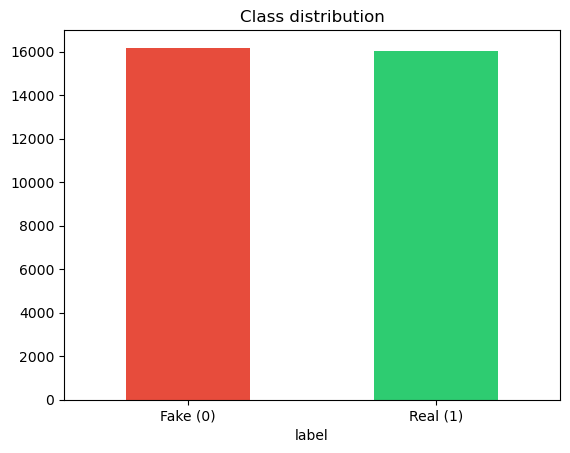

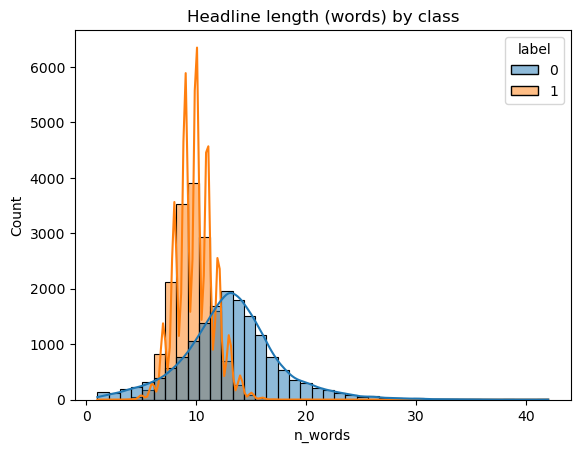

In [4]:
# How balanced are the two classes?
ax = df_train['label'].value_counts().plot(kind='bar', color=['#e74c3c', '#2ecc71'])
ax.set_xticklabels(['Fake (0)', 'Real (1)'], rotation=0)
ax.set_title('Class distribution')
plt.show()

# How long are the headlines, and does it differ by class?
df_train['n_words'] = df_train['headline'].str.split().str.len()
sns.histplot(data=df_train, x='n_words', hue='label', bins=40, kde=True)
plt.title('Headline length (words) by class')
plt.show()

---
# 3. Preprocessing - Sabeur

The goal here is one function, `clean_text()`, that everyone uses. Whatever happens to the text - lowercasing, tokenising, dropping stopwords, lemmatising - happens inside this function so the train and test data go through exactly the same pipeline.

What it does:
1. Lowercase everything (the data is already lowercase but we do it anyway, just in case).
2. Strip out punctuation and digits.
3. Tokenise (`"this is great"` -> `["this", "is", "great"]`).
4. Drop English stopwords and very short tokens.
5. Lemmatise so `running -> run`, `better -> good` (we picked lemmatisation over stemming because it reads better).

After running it on both DataFrames we get a `processed_text` column ready for vectorisation.

In [5]:
STOPWORDS = set(stopwords.words('english'))
LEMMATIZER = WordNetLemmatizer()
PUNCT_RE = re.compile(f'[{re.escape(string.punctuation)}0-9]')


def clean_text(text: str) -> str:
    """Lowercase, strip punctuation/digits, drop stopwords, lemmatise."""
    text = text.lower()
    text = PUNCT_RE.sub(' ', text)
    tokens = word_tokenize(text)
    tokens = [t for t in tokens if t not in STOPWORDS and len(t) > 1]
    tokens = [LEMMATIZER.lemmatize(t) for t in tokens]
    return ' '.join(tokens)


# Quick check on a noisy example
clean_text("Donald Trump sends out EMBARRASSING tweets!!! #fakenews")

'donald trump sends embarrassing tweet fakenews'

In [8]:
df_train['processed_text'] = df_train['headline'].apply(clean_text)
df_test['processed_text'] = df_test['headline'].apply(clean_text)

df_train[['headline', 'processed_text', 'label']]

,label,headline,n_words,processed_text
0,0,donald trump sends out embarrassing new year‚s eve message; this is disturbing,12,donald trump sends embarrassing new year‚s eve message disturbing
1,0,drunk bragging trump staffer started russian collusion investigation,8,drunk bragging trump staffer started russian collusion investigation
2,0,sheriff david clarke becomes an internet joke for threatening to poke people ‚in the eye‚,15,sheriff david clarke becomes internet joke threatening poke people ‚in eye‚
3,0,trump is so obsessed he even has obama‚s name coded into his website (images),14,trump obsessed even obama‚s name coded website image
4,0,pope francis just called out donald trump during his christmas speech,11,pope francis called donald trump christmas speech
...,...,...,...,...
32201,1,tears in rain as thais gather for late king's funeral,10,tear rain thai gather late king funeral
32202,1,pyongyang university needs non-u.s. teachers as travel ban leaves staff shortages,11,pyongyang university need non teacher travel ban leaf staff shortage
32203,1,philippine president duterte to visit japan ahead of key regional summits,11,philippine president duterte visit japan ahead key regional summit
32204,1,japan's abe may have won election\tbut many don't want him as pm,13,japan abe may election many want pm


---
# 4. Feature engineering - Philippe

Now we turn `processed_text` into numbers a model can chew on. A few options on the table:

- **Bag of Words** with `CountVectorizer` - just word counts.
- **TF-IDF** with `TfidfVectorizer` - same idea but downweights words that appear everywhere. Good baseline.
- **n-grams** - throw bigrams in too, sometimes helps catch short phrases.
- **Embeddings** (Word2Vec, GloVe, BERT) - heavier; only if we have time.

One thing to keep in mind: fit the vectorizer **only on the training fold**, then `.transform()` validation and test. Otherwise we're cheating.

# Define Pipelines

In [ ]:
# Define pipelines for different vectorizer + classifier combinations (6 combinations)
pipelines = {
    "BoW + Naive Bayes": Pipeline([
        ("vec", CountVectorizer()), 
        ("clf", MultinomialNB())
    ]),
    "TF-IDF + Naive Bayes": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", MultinomialNB())
    ]),
    "BoW + Logistic Reg": Pipeline([
        ("vec", CountVectorizer()), 
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "TF-IDF + Logistic Reg": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", LogisticRegression(max_iter=1000, random_state=42))
    ]),
    "TF-IDF + Random Forest": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", RandomForestClassifier(random_state=42, n_jobs=-1))
    ]),
    "TF-IDF + Linear SVM": Pipeline([
        ("vec", TfidfVectorizer()), 
        ("clf", LinearSVC(random_state=42))
    ])
}

---
# 5. Training the models - Philippe

We try a few classic text classifiers and pick whichever does best on the validation set:

- Logistic Regression - the usual strong baseline for text.
- Multinomial Naive Bayes - fast, plays nicely with sparse counts.
- Linear SVM - often the winner on TF-IDF.
- (Maybe Random Forest or XGBoost if there's time.)

How we go about it:
1. Stratified train/validation split.
2. Vectorizer + classifier inside a single `sklearn.Pipeline` so there's no leakage.
3. Tune with `GridSearchCV`.
4. Save the winning pipeline with `joblib.dump` so Joao can pick it up.

End result: one fitted `model_pipeline` object that takes a list of cleaned headlines and returns predictions.

# Train / Test Split

In [9]:
X_data = df_train['processed_text']
y_data = df_train['label']

X_train, X_test, y_train, y_test = train_test_split(X_data, y_data, test_size=0.20, random_state=42)
print(f"Train: {len(X_train)} rows | Test: {len(X_test)} rows\n")

Train: 25764 rows | Test: 6442 rows



# Train and evaluate Pipelines, check overfitting

In [14]:
print("Testing combinations pipelines (Checking Train vs Test Accuracy)...\n")
best_baseline_acc = 0

for name, pipe in pipelines.items():
    # Train the pipeline
    pipe.fit(X_train, y_train)
    
    # Predict on both sets to check for overfitting
    acc_train = accuracy_score(y_train, pipe.predict(X_train))
    acc_test = accuracy_score(y_test, pipe.predict(X_test))
    
    print(f"[{name}]")
    print(f"   -> Train Acc: {acc_train:.4f} | Test Acc: {acc_test:.4f}")
    
    # Track the best baseline model
    if acc_test > best_baseline_acc:
        best_baseline_acc = acc_test
        best_baseline_name = name

print(f"\n-----> BEST BASELINE COMBINATION: {best_baseline_name} ({best_baseline_acc:.4f})")

Testing combinations pipelines (Checking Train vs Test Accuracy)...

[BoW + Naive Bayes]
   -> Train Acc: 0.9499 | Test Acc: 0.9334
[TF-IDF + Naive Bayes]
   -> Train Acc: 0.9490 | Test Acc: 0.9319
[BoW + Logistic Reg]
   -> Train Acc: 0.9757 | Test Acc: 0.9362
[TF-IDF + Logistic Reg]
   -> Train Acc: 0.9550 | Test Acc: 0.9337
[TF-IDF + Random Forest]
   -> Train Acc: 1.0000 | Test Acc: 0.9135
[TF-IDF + Linear SVM]
   -> Train Acc: 0.9880 | Test Acc: 0.9382

-----> BEST BASELINE COMBINATION: TF-IDF + Linear SVM (0.9382)


# Hyperparameter Tuning (GridSearchCV)

In [15]:
# Applying on the best baseline combination (TF-IDF + Linear SVM)
pipe_to_tune = Pipeline([
    ("vec", TfidfVectorizer()),
    ("clf", LinearSVC(random_state=42))
])

# We test unigrams vs bigrams, and different regularization strengths (C)
param_grid = {
    'vec__ngram_range': [(1, 1), (1, 2)], # 1 word vs 2 words
    'vec__max_features': [None, 5000],    # Full vocabulary vs limited
    'clf__C': [0.01, 0.05, 0.1, 0.5, 1, 10] # Regularization strength
}

grid_search = GridSearchCV(pipe_to_tune, param_grid, cv=5, scoring='accuracy', n_jobs=-1)
grid_search.fit(X_train, y_train)

tuned_test_acc = accuracy_score(y_test, grid_search.predict(X_test))

print(f"Best parameters found: {grid_search.best_params_}")
print(f"Tuned Model Test Accuracy: {tuned_test_acc:.4f}")

# Select the absolute best model to export
final_best_model = grid_search.best_estimator_

Best parameters found: {'clf__C': 1, 'vec__max_features': None, 'vec__ngram_range': (1, 2)}
Tuned Model Test Accuracy: 0.9429


# Export Pipeline

In [ ]:
output_filename = 'philip_deliverable.pkl'

with open(output_filename, 'wb') as file:
    pickle.dump(final_best_model, file)
    
print(f"\nDeliverable successfully saved as '{output_filename}'. Handing over to Jaos!")

return final_best_model

---
# 6. Evaluation - Joao

Time to see how well the model actually does and where it slips up.

Metrics we care about:
- Accuracy - decent overall summary, but only if classes are balanced.
- Precision - of the headlines we said are real, how many actually are?
- Recall - of the real headlines out there, how many did we catch?
- F1 - the precision/recall combo, usually the most honest one-number summary.
- Confusion matrix - shows where the wrong calls are happening.

After the numbers come out, we eyeball the misclassified headlines. Often there's a pattern (very short headlines, certain topics, etc.) and that feedback helps Sabeur or Philippe tweak earlier stages.

In [ ]:
# Joao - add your code here


---
# 7. Predicting on the test set - Joao

The hard work is done - here we just plug the test data through the same pipeline.

A few things to be careful about:
- Use Sabeur's `clean_text()`. Don't reinvent it.
- Use Philippe's already-fitted `model_pipeline`. Don't refit it on test.
- On the test data: `.transform()` and `.predict()` only. Never `.fit()`.

Steps:
1. Load `testing_data_lowercase_nolabels.csv`.
2. Run `clean_text()` on every headline.
3. `predictions = model_pipeline.predict(processed_test)`.

In [ ]:
# Joao - add your code here


---
# 8. Final output - Joao

What we hand in at the end:
1. `submission.csv` - one column called `prediction`, with 0 or 1 for each test headline, in the original order.
2. `model_pipeline.joblib` - the saved pipeline, in case anyone wants to reproduce the predictions.
3. A short evaluation write-up: the metrics, the confusion matrix, and a few sentences about the most common error patterns we found.

In [ ]:
# Joao - add your code here


---
# 9. Wrap-up and ideas for later

What we ended up with: a small, reproducible pipeline that cleans headlines, turns them into TF-IDF features, runs them through a classifier, and spits out predictions for the unlabelled test set.

Things we could try if we had more time:
- Word embeddings (Word2Vec, GloVe) instead of TF-IDF.
- A pretrained transformer (BERT or RoBERTa) for the heavy-lifting baseline.
- A tiny Streamlit app so anyone can paste a headline and get a verdict.
- Tracking how accuracy holds up over time or across topics.

Teamwork makes the model work.